# The Mathematical Bottleneck: Compressing Language into a vector

i learned that true Semantic Communication requires an **Information Bottleneck**. We cannot transmit a matrix of words; we must squash the entire meaning of a sentence into a single, fixed-size mathematical payload.

In this notebook, we load our PyTorch `SemanticEncoder` and mathematically prove that it compresses sentences of entirely different lengths into the exact same physical payload shape!

In [1]:
import sys
import os
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

sys.path.append(os.path.abspath(r'C:\Users\Shrish\Desktop\semantic-comm\actual_project'))
from src.model import SemanticEncoder

print("loaded.")

loaded.


### Proof 1: Variable Input $\rightarrow$ Fixed Output
We will feed a short 3-word sentence and a long 15-word sentence into the Encoder and print the dimensions of the final Payload.

In [2]:
vocab_size = 500
hidden_dim = 256

encoder = SemanticEncoder(vocab_size=vocab_size, embed_dim=128, hidden_dim=hidden_dim)


short_sentence = torch.randint(1, vocab_size, (1, 3))
long_sentence = torch.randint(1, vocab_size, (1, 15))

hidden_short, cell_short = encoder(short_sentence)
hidden_long, cell_long = encoder(long_sentence)

print(f"Short Sentence Shape: {short_sentence.shape} (1 sentence, 3 words)")
print(f"Long Sentence Shape:  {long_sentence.shape} (1 sentence, 15 words)")


print(f"Short Sentence Payload Shape: {hidden_short.shape}")
print(f"Long Sentence Payload Shape:  {hidden_long.shape}")



Short Sentence Shape: torch.Size([1, 3]) (1 sentence, 3 words)
Long Sentence Shape:  torch.Size([1, 15]) (1 sentence, 15 words)
Short Sentence Payload Shape: torch.Size([1, 1, 256])
Long Sentence Payload Shape:  torch.Size([1, 1, 256])


### Proof 2: The Cascading Effect of Meaning
Because the LSTM processes the sentence recursively, changing even a single word at the beginning of the sentence drastically shifts the final vector payload.

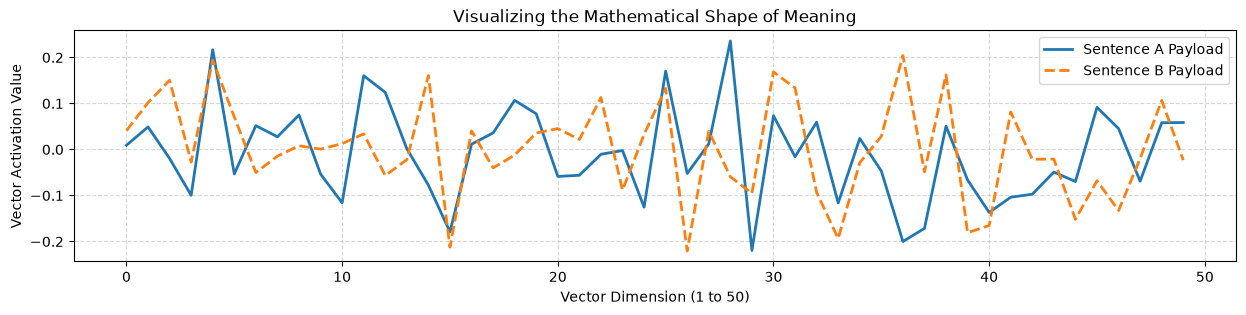

In [6]:

sentence_A = torch.tensor([[10, 20, 30, 40]])
sentence_B = torch.tensor([[10, 20, 30, 499]])

hidden_A, _ = encoder(sentence_A)
hidden_B, _ = encoder(sentence_B)
plt.figure(figsize=(15, 3))
plt.plot(hidden_A[0, 0, :50].detach().numpy(), label='Sentence A Payload', linewidth=2)
plt.plot(hidden_B[0, 0, :50].detach().numpy(), label='Sentence B Payload', linewidth=2, linestyle='dashed')
plt.title("Visualizing the Mathematical Shape of Meaning")
plt.xlabel("Vector Dimension (1 to 50)")
plt.ylabel("Vector Activation Value")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()